# Hodgkin–Huxley → PCA → SINDy (FHN-like structure)

Identify reduced dynamics by applying SINDy to PCA-reduced variables Z.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from model_hh import solve_hh

In [49]:
tf = 100.0
tt = np.linspace(0, 100, 5000)
dt = tt[1] - tt[0]
Iext = 10.0

y0 = [-65, 0.05, 0.6, 0.32]

data = solve_hh(y0, I=Iext, t_final=tf, dt=dt)

t, V, m, h, n, dv, dm, dh, dn = data

In [50]:
X = np.column_stack((V, m, h, n))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

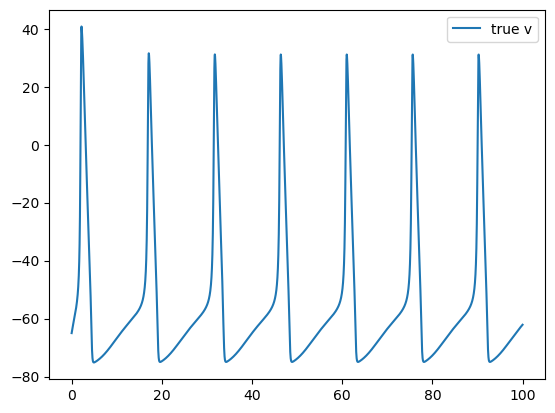

In [51]:
plt.figure()
plt.plot(t, X[:,0], label='true v')
plt.legend()
plt.show()

In [52]:
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', np.sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.70840916 0.27885994]
Total explained variance: 0.9872691035004217


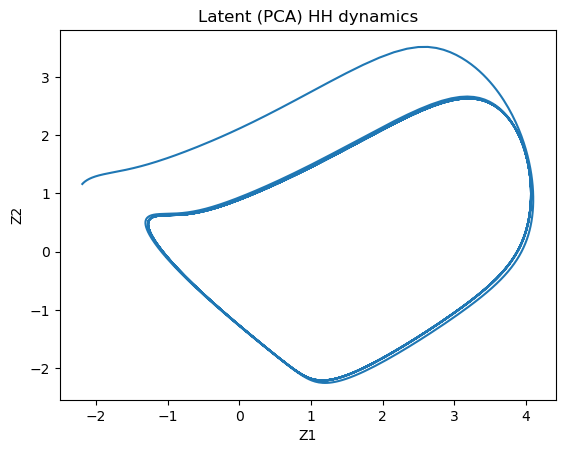

In [53]:
plt.figure()
plt.plot(Z[:,0], Z[:,1])
plt.xlabel('Z1')
plt.ylabel('Z2')
plt.title('Latent (PCA) HH dynamics')
plt.show()

In [54]:
library = ps.PolynomialLibrary(degree=3)
optimizer = ps.STLSQ(threshold=1e-3)

model = ps.SINDy(
    feature_library=library,
    optimizer=optimizer,
    differentiation_method=ps.SmoothedFiniteDifference(),
    feature_names=['z1','z2']
)

model.fit(Z, t=dt)
model.print()

(z1)' = -0.356 1 + 0.469 z1 + 2.019 z2 + 0.430 z1^2 + 1.808 z1 z2 + 1.224 z2^2 + -0.150 z1^3 + -0.421 z1^2 z2 + -0.431 z1 z2^2 + -0.207 z2^3
(z2)' = -0.459 1 + 0.046 z1 + 0.982 z2 + 0.534 z1^2 + 1.771 z1 z2 + 1.114 z2^2 + -0.163 z1^3 + -0.427 z1^2 z2 + -0.422 z1 z2^2 + -0.216 z2^3


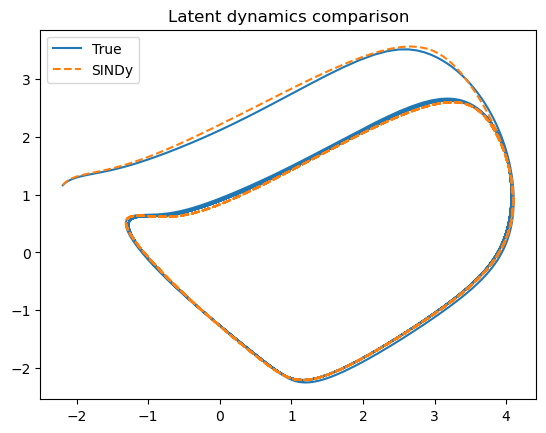

In [55]:
Z_sim = model.simulate(Z[0], t)

plt.figure()
plt.plot(Z[:,0], Z[:,1], label='True')
plt.plot(Z_sim[:,0], Z_sim[:,1], '--', label='SINDy')
plt.legend()
plt.title('Latent dynamics comparison')
plt.show()

### Forcing FHN-like model structure

In [56]:
# Define allowed functions
fhn_functions = [
    lambda x, y: x,              # z1
    lambda x, y: y,              # z2
    lambda x, y: x**3,           # z1^3
    lambda x, y: np.ones_like(x)  # constant
]

fhn_names = [
    lambda x, y: "z0",
    lambda x, y: "z1",
    lambda x, y : "z0^3",
    lambda x, y: "1"
]

fhn_library = ps.CustomLibrary(
    library_functions=fhn_functions,
    function_names=fhn_names
)

# opt = ps.STLSQ(threshold=0.1), # works too
# opt = ps.STLSQ(threshold=0.075)  # works too - 0.09
# opt = ps.SSR(alpha=1.0)

opt = ps.SR3(threshold=0.1)

model_fhn = ps.SINDy(
    feature_library=fhn_library,
    optimizer=opt,
    feature_names=["z0", "z1"]
)

model_fhn.fit(Z, t=dt)
model_fhn.print()

(z0)' = 1.208 z0 + 1.549 z1 + -0.118 z0^3 + 0.797 1
(z1)' = -0.393 z0 + -0.005 z1 + -0.007 1


In [57]:
Z_sim2 = model_fhn.simulate(Z[0], t)

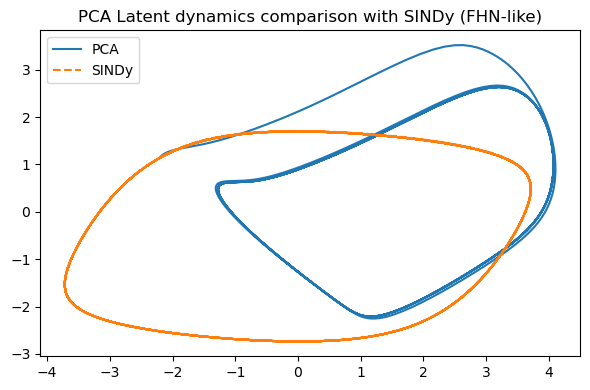

In [58]:
plt.figure(figsize=(6,4))
plt.plot(Z[:,0], Z[:,1], label='PCA')
plt.plot(Z_sim2[:,0], Z_sim2[:,1], '--', label='SINDy')
plt.legend()
plt.title('PCA Latent dynamics comparison with SINDy (FHN-like)')
plt.tight_layout()
plt.savefig('fig_hh_pca_fhn_like_phase.pdf',dpi=300)
plt.show()

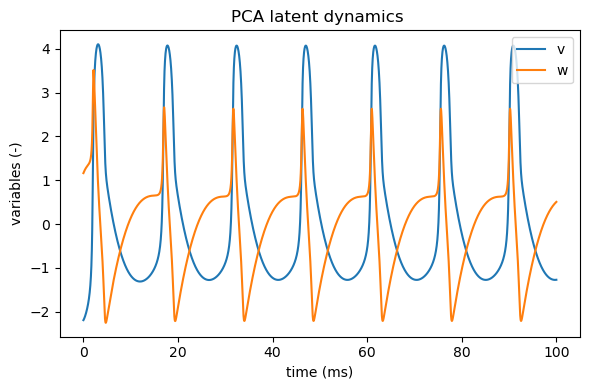

In [59]:
plt.figure(figsize=(6,4))
plt.plot(t, Z[:,0], label='v')
plt.plot(t, Z[:,1], label='w')
plt.xlabel('time (ms)')
plt.ylabel('variables (-)')
plt.title('PCA latent dynamics ')
plt.legend()
plt.tight_layout()
plt.savefig('fig_hh_pca_fhn_like_time.pdf',dpi=300)
plt.show()

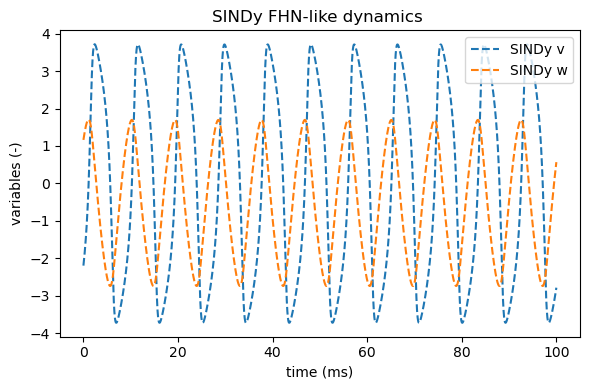

In [60]:
plt.figure(figsize=(6,4))
plt.plot(t, Z_sim2[:,0], '--', label='SINDy v')
plt.plot(t, Z_sim2[:,1], '--', label='SINDy w')
plt.legend()
plt.xlabel('time (ms)')
plt.ylabel('variables (-)')
plt.title('SINDy FHN-like dynamics ')
plt.tight_layout()
plt.savefig('fig_hh_pca_fhn_like_time.pdf',dpi=300)
plt.show()

### Rescaling model coefficients of eq.2 to get it on a different time-scale

[[ 1.20753065e+00  1.54851845e+00 -1.17989781e-01  7.97312723e-01]
 [-3.93435232e-02 -4.88000589e-04  0.00000000e+00 -6.53058710e-04]]


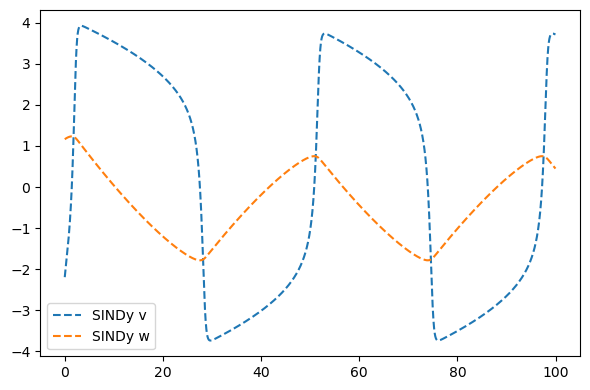

In [61]:
model_fhn.coefficients()[1,:] *= 0.1

print(model_fhn.coefficients())
Z_sim3 = model_fhn.simulate(Z[0], t)

plt.figure(figsize=(6,4))
plt.plot(t, Z_sim3[:,0], '--', label='SINDy v')
plt.plot(t, Z_sim3[:,1], '--', label='SINDy w')
plt.legend()
plt.tight_layout()
plt.savefig('fig_hh_pca_fhn_like_time_rescaled.pdf',dpi=300)
plt.show()